
--- Running Question 2: two_gaussians (MSE Loss) ---
k=2 | Lowest Val Loss: 0.02107
k=3 | Lowest Val Loss: 0.02098
k=5 | Lowest Val Loss: 0.02089
k=7 | Lowest Val Loss: 0.02090
k=9 | Lowest Val Loss: 0.02078
WINNER: k=9 | Accuracy: 0.9100

Hyperparameters for two_gaussians
Dataset                  : two_gaussians
Best Hidden Nodes (k)    : 9
Learning Rate            : 0.5
Max Epochs               : 2000
Patience                 : 100
Optimizer                : GD
Loss Function            : MSELoss
Activation               : Tanh
Final Activation         : Sigmoid



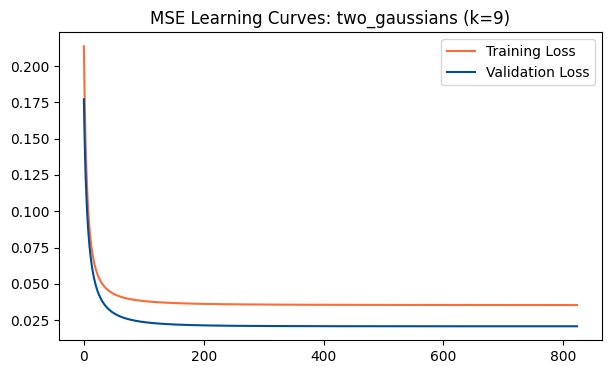

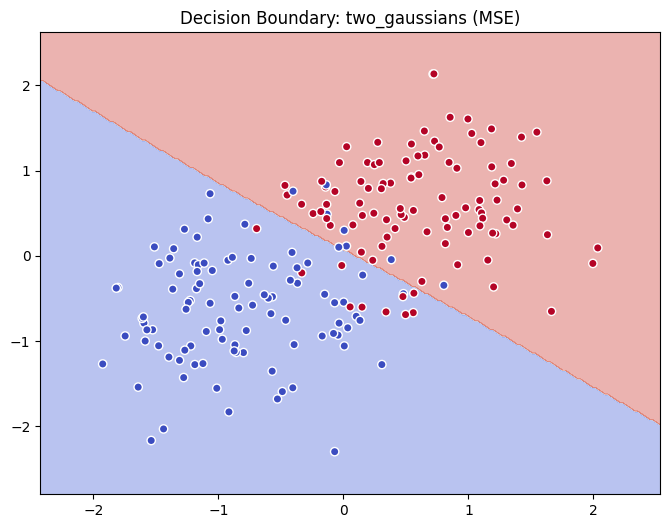


--- Running Question 2: xor (MSE Loss) ---
k=2 | Lowest Val Loss: 0.19693
k=3 | Lowest Val Loss: 0.10791
k=5 | Lowest Val Loss: 0.05535
k=7 | Lowest Val Loss: 0.04563
k=9 | Lowest Val Loss: 0.04249
WINNER: k=9 | Accuracy: 0.9700

Hyperparameters for xor
Dataset                  : xor
Best Hidden Nodes (k)    : 9
Learning Rate            : 0.5
Max Epochs               : 2000
Patience                 : 100
Optimizer                : GD
Loss Function            : MSELoss
Activation               : Tanh
Final Activation         : Sigmoid



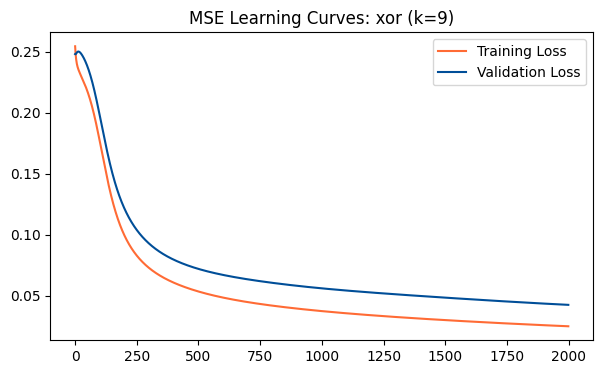

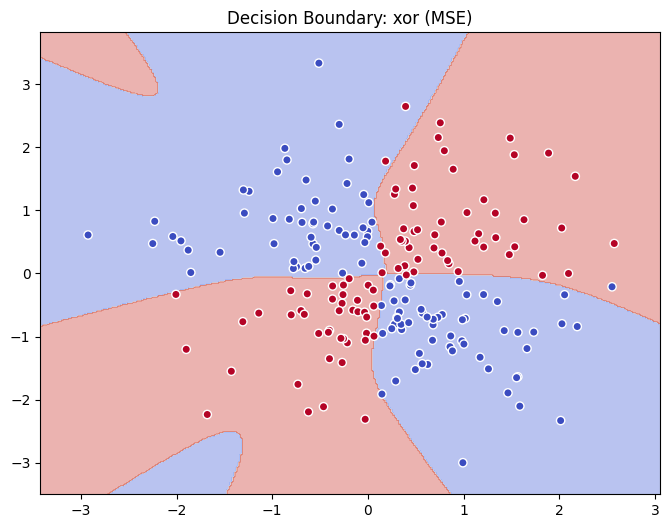


--- Running Question 2: center_surround (MSE Loss) ---
k=2 | Lowest Val Loss: 0.10218
k=3 | Lowest Val Loss: 0.03674
k=5 | Lowest Val Loss: 0.02795
k=7 | Lowest Val Loss: 0.03259
k=9 | Lowest Val Loss: 0.02750
WINNER: k=9 | Accuracy: 0.7650

Hyperparameters for center_surround
Dataset                  : center_surround
Best Hidden Nodes (k)    : 9
Learning Rate            : 0.5
Max Epochs               : 2000
Patience                 : 100
Optimizer                : GD
Loss Function            : MSELoss
Activation               : Tanh
Final Activation         : Sigmoid



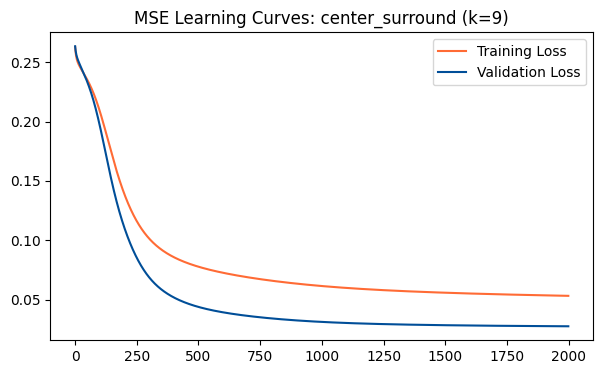

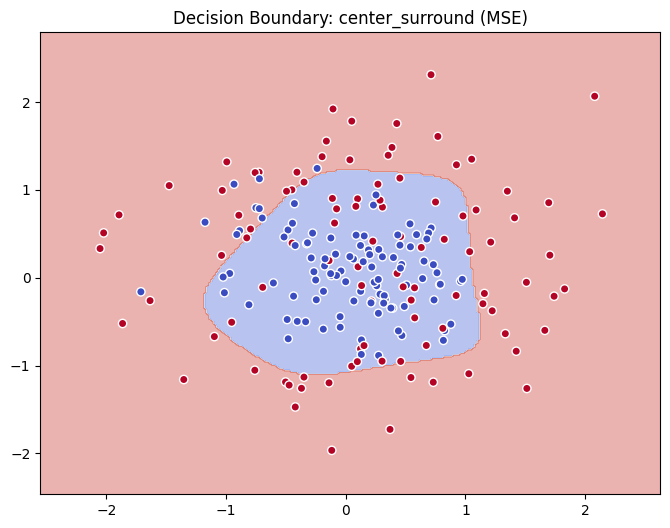


--- Running Question 2: spiral (MSE Loss) ---
k=2 | Lowest Val Loss: 0.15508
k=3 | Lowest Val Loss: 0.13719
k=5 | Lowest Val Loss: 0.05994
k=7 | Lowest Val Loss: 0.04138
k=9 | Lowest Val Loss: 0.03045
WINNER: k=9 | Accuracy: 1.0000

Hyperparameters for spiral
Dataset                  : spiral
Best Hidden Nodes (k)    : 9
Learning Rate            : 0.5
Max Epochs               : 2000
Patience                 : 100
Optimizer                : GD
Loss Function            : MSELoss
Activation               : Tanh
Final Activation         : Sigmoid



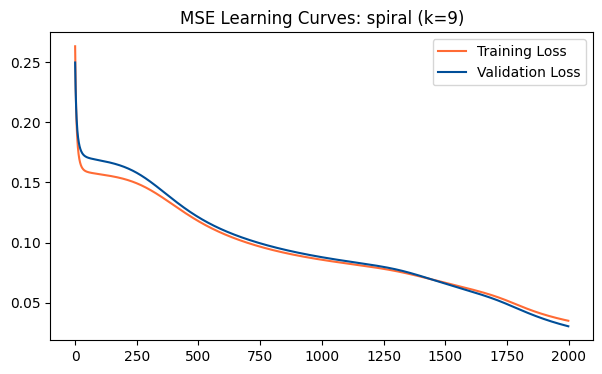

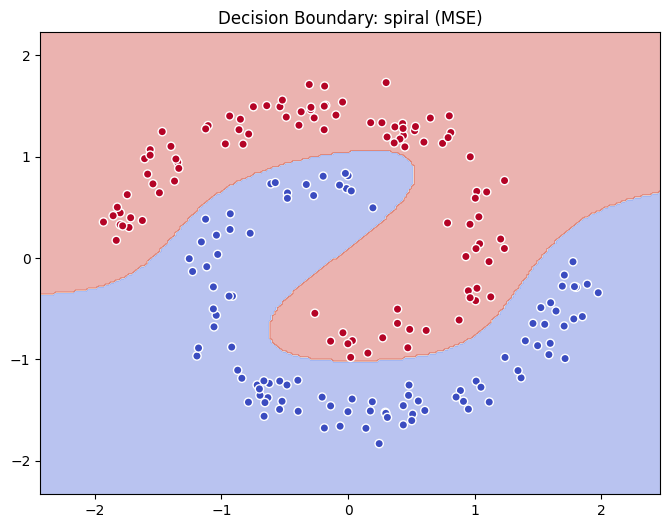

In [11]:
"""Gradient Descent using MSE Loss for various datasets."""

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# standard seed for consistency across the project
torch.manual_seed(42)
np.random.seed(42)

# List of datasets to process for the MSE task
dataset_names = ['two_gaussians', 'xor', 'center_surround', 'spiral']
mse_final_results = []

for name in dataset_names:
    print(f"\n--- Running Question 2: {name} (MSE Loss) ---")
    
    # Load raw data files
    df_train = pd.read_csv(f'{name}_train.csv')
    df_valid = pd.read_csv(f'{name}_valid.csv')
    df_test = pd.read_csv(f'{name}_test.csv')

    # MSE setup: We need float labels in a (N, 1) column format
    x_train_raw = df_train[['x1', 'x2']].values
    y_train_raw = df_train['label'].values.astype(np.float32).reshape(-1, 1)
    
    x_val_raw = df_valid[['x1', 'x2']].values
    y_val_raw = df_valid['label'].values.astype(np.float32).reshape(-1, 1)
    
    x_test_raw = df_test[['x1', 'x2']].values
    y_test_raw = df_test['label'].values.astype(np.float32).reshape(-1, 1)

    # Normalize based on the training data stats
    avg = x_train_raw.mean(axis=0)
    std_dev = x_train_raw.std(axis=0)
    std_dev[std_dev == 0] = 1 # safety check
    
    x_train_scaled = (x_train_raw - avg) / std_dev
    x_val_scaled = (x_val_raw - avg) / std_dev
    x_test_scaled = (x_test_raw - avg) / std_dev

    # Convert to torch tensors
    train_features = torch.tensor(x_train_scaled, dtype=torch.float32)
    train_targets = torch.tensor(y_train_raw, dtype=torch.float32)
    
    val_features = torch.tensor(x_val_scaled, dtype=torch.float32)
    val_targets = torch.tensor(y_val_raw, dtype=torch.float32)
    
    test_features = torch.tensor(x_test_scaled, dtype=torch.float32)
    test_targets = torch.tensor(y_test_raw, dtype=torch.float32)

    best_overall_v_loss = float('inf')
    best_k_val = -1
    best_weights_overall = None
    
    # dictionary for tracking stats of the top performing k
    top_stats = {}

    # Experiment with different hidden sizes (k)
    for k in [2, 3, 5, 7, 9]:
        # MLP for MSE: Input -> Hidden -> Tanh -> Single Output -> Sigmoid
        model = nn.Sequential(
            nn.Linear(2, k),
            nn.Tanh(),
            nn.Linear(k, 1),
            nn.Sigmoid() 
        )

        optimizer = optim.SGD(model.parameters(), lr=0.5)
        loss_function = nn.MSELoss()

        t_loss_history = []
        v_loss_history = []
        
        # Early stopping setup
        min_v_loss_this_k = float('inf')
        patience_counter = 0
        best_state_this_k = None

        for epoch in range(2000):
            model.train()
            optimizer.zero_grad()
            
            # Forward pass
            preds = model(train_features)
            loss = loss_function(preds, train_targets)
            
            # Backprop
            loss.backward()
            optimizer.step()
            
            t_loss_history.append(loss.item())

            # Validation check
            model.eval()
            with torch.no_grad():
                v_preds = model(val_features)
                v_loss = loss_function(v_preds, val_targets)
                v_loss_history.append(v_loss.item())

                if v_loss < min_v_loss_this_k:
                    min_v_loss_this_k = v_loss
                    best_state_this_k = model.state_dict().copy()
                    patience_counter = 0
                else:
                    patience_counter += 1

            # Stop if val loss hasn't improved in 100 epochs
            if patience_counter >= 100:
                break
        
        print(f"k={k} | Lowest Val Loss: {min_v_loss_this_k:.5f}")

        # Update the overall winner
        if min_v_loss_this_k < best_overall_v_loss:
            best_overall_v_loss = min_v_loss_this_k
            best_k_val = k
            best_weights_overall = best_state_this_k
            top_stats['train_losses'] = t_loss_history
            top_stats['val_losses'] = v_loss_history

    # --- FINAL EVALUATION FOR BEST K ---
    
    # Setup winning model
    final_net = nn.Sequential(nn.Linear(2, best_k_val), nn.Tanh(), nn.Linear(best_k_val, 1), nn.Sigmoid())
    final_net.load_state_dict(best_weights_overall)
    
    final_net.eval()
    with torch.no_grad():
        test_out = final_net(test_features)
        # Binary rounding at 0.5 threshold
        final_preds = (test_out >= 0.5).float()
        acc = (final_preds == test_targets).float().mean().item()
    
    print(f"WINNER: k={best_k_val} | Accuracy: {acc:.4f}")
    mse_final_results.append({'dataset': name, 'best_k': best_k_val, 'test_acc': acc})
    experiment_config = {
        'Dataset': name,
        'Best Hidden Nodes (k)': best_k_val,
        'Learning Rate': 0.5,
        'Max Epochs': 2000,
        'Patience': 100,
        'Optimizer': 'GD',
        'Loss Function': 'MSELoss',
        'Activation': 'Tanh',
        'Final Activation': 'Sigmoid',
    }

    print("\n" + "="*30)
    print(f"Hyperparameters for {name}")
    print("="*30)
    for key, value in experiment_config.items():
        print(f"{key:<25}: {value}")
    print("="*30 + "\n")

    # Loss Curves
    plt.figure(figsize=(7, 4))
    plt.plot(top_stats['train_losses'], label='Training Loss', color='#FF6B35')
    plt.plot(top_stats['val_losses'], label='Validation Loss', color='#004E98')
    plt.title(f"MSE Learning Curves: {name} (k={best_k_val})")
    plt.legend()
    plt.show()

    # Decision Boundary
    x0, x1 = x_test_scaled[:, 0].min() - 0.5, x_test_scaled[:, 0].max() + 0.5
    y0, y1 = x_test_scaled[:, 1].min() - 0.5, x_test_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, 0.02), np.arange(y0, y1, 0.02))
    
    grid_coords = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        grid_out = final_net(grid_coords)
        Z = (grid_out >= 0.5).float().numpy().reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=y_test_raw.flatten(), edgecolors='white', cmap='coolwarm')
    plt.title(f"Decision Boundary: {name} (MSE)")
    plt.show()


To adapt the network for Mean Squared Error (MSE), I used a single output node with a sigmoid activation so predictions stay in the (0, 1) range, allowing binary classification to be treated as regression toward 0/1 targets. Compared to cross-entropy, I observed that MSE gradients weaken as the sigmoid output approaches 0 or 1 due to saturation, so the optimizer often needed more epochs (up to about 2000) or a higher early-stopping patience (around 100) to reach accuracy similar to the cross-entropy (MCE) implementation.